In [2]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [ ]:
################################
#RUNNING

In [2]:
#W Budgets

#Making vertical profile of cloudy updrafts
if 'emptylike' not in globals():
    print('loading neccessary variables')

    #Full Variables (W, QV, QC, QI)
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qv data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qi data
    qc_plus_qi=qc_data+qi_data
    emptylike=True

#W Budget Variables
variable='wb_hadv'; one_data=data[variable].data #'w budget: horizontal advection (non-diff component)'
variable='wb_vadv'; two_data=data[variable].data #'w budget: vertical advection (non-diff component)'
variable='wb_hidiff'; three_data=data[variable].data #'w budget: horiz implicit diffusion'
variable='wb_vidiff'; four_data=data[variable].data #'w budget: vert implicit diffusion'
variable='wb_hturb'; five_data=data[variable].data #'w budget: horizontal parameterized turbulence'
variable='wb_vturb'; six_data=data[variable].data #'w budget: vertical parameterized turbulence'
variable='wb_pgrad'; seven_data=data[variable].data #'w budget: pressure gradient'
variable='wb_rdamp'; eight_data=data[variable].data #'w budget: Rayleigh damper'
variable='wb_buoy'; nine_data=data[variable].data #'w budget: buoyancy'
print('done loading')

#thresholds
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6 

def final_profile(var,type):
    nt=len(data['time'])
        
    #get qc and interpolated w 

    # finds regions that match the threshold
    if type=="general":
        where_updraft=np.where((w_data>=w_thresh1)) #uncomment for "general updraft"
    elif type=='cloudy': 
        where_updraft=np.where((w_data>=w_thresh2) & (qc_plus_qi>=qcqi_thresh)) #uncomment for "cloudy updraft" 
    
    #creates profile storage and adds z column    
    zhs=data['zh'].values
    profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs

    #get incidies associated with threshold mask
    t_ind, z_ind, y_ind, x_ind = where_updraft

    #gets data associated with threshold mask
    if var=='w':
        masked_data=w_data[where_updraft]
    elif var == 'wb_hadv':
        masked_data = one_data[where_updraft]  # Horizontal advection (non-diff component)
    elif var == 'wb_vadv':
        masked_data = two_data[where_updraft]  # Vertical advection (non-diff component)
    elif var == 'wb_hidiff':
        masked_data = three_data[where_updraft]  # Horizontal implicit diffusion
    elif var == 'wb_vidiff':
        masked_data = four_data[where_updraft]  # Vertical implicit diffusion
    elif var == 'wb_hturb':
        masked_data = five_data[where_updraft]  # Horizontal parameterized turbulence
    elif var == 'wb_vturb':
        masked_data = six_data[where_updraft]  # Vertical parameterized turbulence
    elif var == 'wb_pgrad':
        masked_data = seven_data[where_updraft]  # Pressure gradient
    elif var == 'wb_rdamp':
        masked_data = eight_data[where_updraft]  # Rayleigh damper
    elif var == 'wb_buoy':
        masked_data = nine_data[where_updraft]  # Buoyancy


    #bin masked values by z level
    for (kh,value) in zip(z_ind,masked_data):
        profile_array[kh,0]+=value #adds data to first column
        profile_array[kh,1]+=1 #adds +1 counter to 2nd column
    return profile_array

loading neccessary variables
done loading


In [3]:
#Final_Profile Function
label=1

yes_run=False
yes_run=True #uncomment if running

if yes_run==True: 
    dim='1km' 
    
    for type in ["general","cloudy"]: #TESTING
        print(f'currently on type {type}')
        
        vars = [
            'w',
            'wb_hadv',
            'wb_vadv', 
            'wb_hidiff',
            'wb_vidiff',
            'wb_hturb',
            'wb_vturb',
            'wb_pgrad',
            'wb_rdamp',
            'wb_buoy'
        ]
        for var in vars:
            print(f'working on {var}')
            globals()[f"profile_{var}"]=final_profile(var,type)
        print('done')
        
        #Saving eulerian_profiles
        import h5py
        if dim=='1km':
            if type == "general":
                output_file = dir+f'Project_Algorithms/plots/job_out/1km_general_eulerian_WBUDGET_profiles_wthresh{label}.h5' #limited
            elif type == "cloudy":
                output_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_eulerian_WBUDGET_profiles_wthresh{label}.h5'
        
        with h5py.File(output_file, 'w') as f:
            f.create_dataset('profile_w', data=profile_w, compression="gzip")
            f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
            f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
            f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
            f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
            f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
            f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
            f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
            f.create_dataset('profile_wb_rdamp', data=profile_wb_rdamp, compression="gzip")
            f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")

currently on type general
working on w
working on wb_hadv
working on wb_vadv
working on wb_hidiff
working on wb_vidiff
working on wb_hturb
working on wb_vturb
working on wb_pgrad
working on wb_rdamp
working on wb_buoy
done
currently on type cloudy
working on w
working on wb_hadv
working on wb_vadv
working on wb_hidiff
working on wb_vidiff
working on wb_hturb
working on wb_vturb
working on wb_pgrad
working on wb_rdamp
working on wb_buoy
done


In [3]:
#QV Budgets

#Making vertical profile of cloudy updrafts

#Making vertical profile of cloudy updrafts
if 'emptylike' not in globals():
    print('loading neccessary variables')

    #Full Variables (W, QV, QC, QI)
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qv data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qi data
    qc_plus_qi=qc_data+qi_data
    emptylike=True

#QV Budget Variables
print('loading variables')
variable='qvb_hadv'; one_data=data[variable].data #'qv budget: horizontal advection (non-diff component)'
variable='qvb_vadv'; two_data=data[variable].data #'qv budget: vertical advection (non-diff component)'
variable='qvb_hidiff'; three_data=data[variable].data #'qv budget: horiz implicit diffusion'
variable='qvb_vidiff'; four_data=data[variable].data #'qv budget: vert implicit diffusion'
variable='qvb_hturb'; five_data=data[variable].data #'qv budget: horizontal parameterized turbulence'
variable='qvb_vturb'; six_data=data[variable].data #'qv budget: vertical parameterized turbulence'
variable='qvb_mp'; seven_data=data[variable].data #'qv budget: microphysics scheme'

# #QV Tendency Variables
# variable='qt_cond'; eight_data=data[variable].data #'qv tendency: condensation'
# variable='qt_evac'; nine_data=data[variable].data #'qv tendency: cloudwater evaporation'
# variable='qt_evar'; ten_data=data[variable].data #'qv tendency: rainwater evaporation'
print('done loading')
    
#thresholds
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6 

def final_profile(var,type):

    nt=len(data['time'])
        
    #get qc and interpolated w 

    # finds regions that match the threshold
    if type=="general":
        where_updraft=np.where((w_data>=w_thresh1)) #uncomment for "general updraft"
    elif type=='cloudy': 
        where_updraft=np.where((w_data>=w_thresh2) & (qc_plus_qi>=qcqi_thresh)) #uncomment for "cloudy updraft" 
    
    #creates profile storage and adds z column    
    zhs=data['zh'].values
    profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs

    #get incidies associated with threshold mask
    t_ind, z_ind, y_ind, x_ind = where_updraft

    #gets data associated with threshold mask
    if var=='qv':
        masked_data=qv_data[where_updraft]
    elif var=='qc':
        masked_data=qc_plus_qi[where_updraft] #qc+qi used for qc
    elif var == 'qvb_hadv':
        masked_data = one_data[where_updraft]  # Horizontal advection (non-diff component)
    elif var == 'qvb_vadv':
        masked_data = two_data[where_updraft]  # Vertical advection (non-diff component)
    elif var == 'qvb_hidiff':
        masked_data = three_data[where_updraft]  # Horizontal implicit diffusion
    elif var == 'qvb_vidiff':
        masked_data = four_data[where_updraft]  # Vertical implicit diffusion
    elif var == 'qvb_hturb':
        masked_data = five_data[where_updraft]  # Horizontal parameterized turbulence
    elif var == 'qvb_vturb':
        masked_data = six_data[where_updraft]  # Vertical parameterized turbulence
    elif var == 'qvb_mp':
        masked_data = seven_data[where_updraft]  #Microphysics
    # elif var == 'qt_cond':
    #     masked_data = eight_data[where_updraft]  
    # elif var == 'qt_evac':
    #     masked_data = nine_data[where_updraft] 
    # elif var == 'qt_evar':
    #     masked_data = ten_data[where_updraft]  


    #bin masked values by z level
    for (kh,value) in zip(z_ind,masked_data):
        profile_array[kh,0]+=value #adds data to first column
        profile_array[kh,1]+=1 #adds +1 counter to 2nd column
    return profile_array

done loading


In [6]:
#Final_Profile Function
label=1

yes_run=False
yes_run=True #uncomment if running

if yes_run==True: 
    dim='1km' 
    
    for type in ["general","cloudy"]:
        print(f'currently on type {type}')
        
        vars = [
            'qv',
            'qc',
            'qvb_hadv',      # Horizontal advection (non-diff component)
            'qvb_vadv',      # Vertical advection (non-diff component)
            'qvb_hidiff',    # Horizontal implicit diffusion
            'qvb_vidiff',    # Vertical implicit diffusion
            'qvb_hturb',     # Horizontal parameterized turbulence
            'qvb_vturb',     # Vertical parameterized turbulence
            'qvb_mp'        # Microphysics
            # 'qt_cond',      
            # 'qt_evac',       
            # 'qt_evar'        
        ]
        for var in vars:
            print(f'working on {var}')
            globals()[f"profile_{var}"]=final_profile(var,type)
        print('done')
        
        #Saving eulerian_profiles
        import h5py
        if dim=='1km':
            if type == "general":
                output_file = dir+f'Project_Algorithms/plots/job_out/1km_general_eulerian_QVBUDGET_profiles_wthresh{label}.h5' #limited
            elif type == "cloudy":
                output_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_eulerian_QVBUDGET_profiles_wthresh{label}.h5'
        
        with h5py.File(output_file, 'w') as f:
            f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
            f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
            f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")        # Horizontal advection (non-diff component)
            f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")        # Vertical advection (non-diff component)
            f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")    # Horizontal implicit diffusion
            f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")    # Vertical implicit diffusion
            f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")      # Horizontal parameterized turbulence
            f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")      # Vertical parameterized turbulence
            f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")            # Microphysics
            # f.create_dataset('profile_qt_cond', data=profile_qt_cond, compression="gzip")          
            # f.create_dataset('profile_qt_evac', data=profile_qt_evac, compression="gzip")          
            # f.create_dataset('profile_qt_evar', data=profile_qt_evar, compression="gzip")          


currently on type general
working on qv
working on qc
working on qvb_hadv
working on qvb_vadv
working on qvb_hidiff
working on qvb_vidiff
working on qvb_hturb
working on qvb_vturb
working on qvb_mp
done
currently on type cloudy
working on qv
working on qc
working on qvb_hadv
working on qvb_vadv
working on qvb_hidiff
working on qvb_vidiff
working on qvb_hturb
working on qvb_vturb
working on qvb_mp
done


In [ ]:
###########################
#Plotting

In [10]:
def fix_x_limits(axes):
    #Bounds all plots by min and max of the current xlims, so all subplots match
    #Provide Axises in terms of [ax1,ax2,...]
    
    # Collect x-limits from all axes
    xlims = [axis.get_xlim() for axis in axes]
    mins = [xlim[0] for xlim in xlims]
    maxes = [xlim[1] for xlim in xlims]
    
    # Find the total min and max
    total_min = min(mins)
    total_max = max(maxes)
    result = (total_min, total_max)
    print(result)
    
    # Set the same x-limits for all axes
    for axis in axes:
        axis.set_xlim(result)

currently on type general
currently on type cloudy
(0.11491929117973067, 3.8182075514082614)
(-0.11925057610475599, 0.1191570802329886)


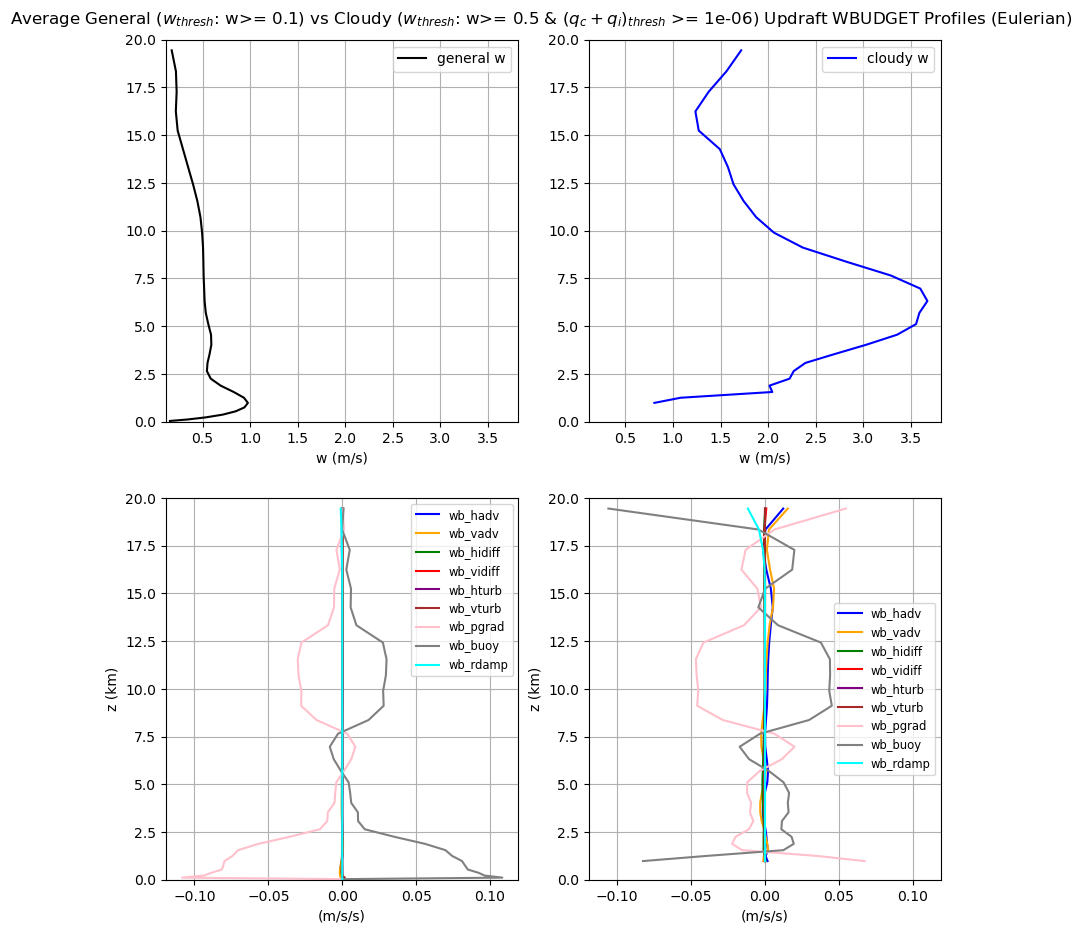

In [15]:
#WBUDGET
label=1

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'
# dim='250m'
label=1

#Uses Plotting Function 
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"Average General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft WBUDGET Profiles (Eulerian)")
ax1, ax2, ax3, ax4 = axs.flatten()

####################################################################
for type in ["general","cloudy"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='general':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_eulerian_WBUDGET_profiles_wthresh{label}.h5' #limited
        elif type=='cloudy':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_eulerian_WBUDGET_profiles_wthresh{label}.h5'
    
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy
        


    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy',
    'wb_rdamp'
]
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    # for var in vars:
    #     out_profile=globals()[f"out_{var}"]
    #     minmax=(np.min(out_profile[:,0]),np.max(out_profile[:,0]))

    if type=='general':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=20)
        axis.set_xlabel('w (m/s)')
        axis.legend()
        axis=ax3
    if type=='cloudy':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        axis.set_ylim(bottom=0,top=20)
        axis.set_xlabel('w (m/s)')
        axis.legend()
        axis=ax4
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        axis.set_ylim(bottom=0,top=20)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        axis.legend(fontsize='small'); #add legend

#FIXING X LIMITS
fix_x_limits([ax1, ax2])
fix_x_limits([ax3, ax4])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/1km_eulerian_generalvscloudy_updraft_WBUDGET_profile_wthresh{label}.jpg', bbox_inches='tight', dpi=300) 
# if dim=='250m'

currently on type general
currently on type cloudy
(-0.8167605869600362, 17.246632881214833)
(-0.006678066404739461, 0.007938532726468528)


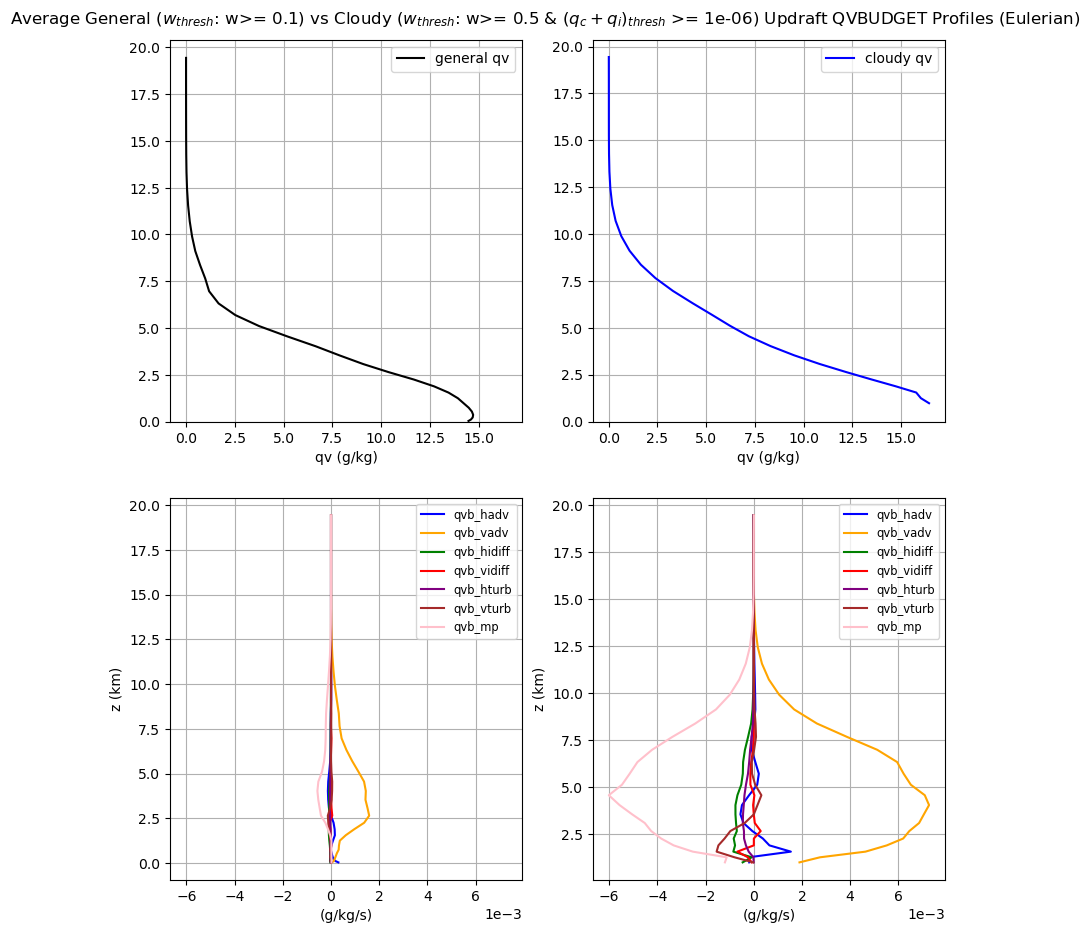

In [12]:
#QV BUDGETS
from matplotlib.ticker import ScalarFormatter
label=1

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'
label=1

#Uses Plotting Function 
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"Average General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft QVBUDGET Profiles (Eulerian)")
ax1, ax2, ax3, ax4 = axs.flatten()

####################################################################
for type in ["general","cloudy"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='general':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_eulerian_QVBUDGET_profiles_wthresh{label}.h5' #limited
        elif type=='cloudy':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_eulerian_QVBUDGET_profiles_wthresh{label}.h5' 
    
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff']) 
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  
        profile_wb_vidiff = np.array(f['profile_qvb_vidiff'])  
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  
        profile_qvb_mp = np.array(f['profile_qvb_mp']) 

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        globals()[f"out_{var}"][:,0]*=1000

    if type=='general':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0)
        axis.set_xlabel('qv (g/kg)')
        axis.legend()
        axis=ax3
    if type=='cloudy':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        axis.set_ylim(bottom=0)
        axis.set_xlabel('qv (g/kg)')
        axis.legend()
        axis=ax4
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        axis.legend(fontsize='small'); #add legend
        axis.xaxis.set_major_formatter(ScalarFormatter())
        axis.xaxis.get_major_formatter().set_powerlimits((-1, 1))  # Set limits for scientific notation

#FIXING X LIMITS
fix_x_limits([ax1, ax2])
fix_x_limits([ax3, ax4])
            
#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/1km_eulerian_generalvscloudy_updraft_QVBUDGET_profile_wthresh{label}.jpg', bbox_inches='tight', dpi=300) 
#limited

In [44]:
# #QV Tendencies
# #QV BUDGETS
# from matplotlib.ticker import ScalarFormatter

# import h5py
# #Produced averaged profiles for plotting
# def averaged_profiles(var):
#     profile=globals()[f"profile_{var}"]

#     out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
#     out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
#     return out_var

# ####################################################################
# dim='1km'

# #Uses Plotting Function 
# fig, axs = plt.subplots(3, 2, figsize=(10, 10))
# plt.subplots_adjust(top=0.95)

# fig.suptitle(f"Average Eulerian General and Cloudy Updraft QVBUDGET Property Profiles")
# ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

# ####################################################################
# for type in ["general","cloudy"]:
#     print(f'currently on type {type}')
    
#     if dim=='1km':
#         if type=='general':
#             input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_eulerian_QVBUDGET_profiles_wthresh{w_thresh}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_eulerian_QVBUDGET_profiles_wthresh{w_thresh}.h5' 
    
#     with h5py.File(input_file, 'r') as f:
#         profile_qv = np.array(f['profile_qv'])  
#         profile_qc = np.array(f['profile_qc'])  
#         profile_qt_cond = np.array(f['profile_qt_cond'])  
#         profile_qt_evac = np.array(f['profile_qt_evac'])  
#         profile_qt_evar = np.array(f['profile_qt_evar'])  



#     #Plotting function
#     def plotting(out_var,axis,label,color):
#         axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
#         axis.grid(True)
    
#     #Uses Averaged_Profiles Function
#     vars = [
#         'qv',
#         'qt_cond',
#         'qt_evac',
#         'qt_evar',
#         'qc'
#     ]
    
#     colors = [
#     'black',    
#     'blue',     
#     'orange',   
#     'green',    
#     'red',      
#     'purple',   
#     'brown',    
#     'pink',     
#     'grey',
#     'cyan'
# ]

#     for var in vars:
#         globals()[f"out_{var}"]=averaged_profiles(var)
#         globals()[f"out_{var}"][:,0]*=1000
    
#     if type=='general':
#         axis=ax1
#         plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
#         axis.set_xlabel('qv (g/kg)')
#         axis.legend()
#         axis=ax3
#     if type=='cloudy':
#         axis=ax2
#         plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
#         axis.set_xlabel('qv (g/kg)')
#         axis.legend()
#         axis=ax4

#     for var,xlabel,color in zip(vars[1:-1],vars[1:-1],colors[1:-1]):
#         globals()[f"out_{var}"][:,0]*=1000
#         plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
#         axis.set_ylabel('z (km)');
#         axis.set_xlabel('(g/kg/s)')
#         axis.legend(); #add legend
#         axis.xaxis.set_major_formatter(ScalarFormatter())
#         axis.xaxis.get_major_formatter().set_powerlimits((-1, 1))  # Set limits for scientific notation
#     if type=='general':
#         axis=ax5
#         plotting(out_qc,axis,label=f'{type} ' + vars[4],color=colors[0])
#         axis.set_xlabel('qc (g/kg)')
#         axis.legend()
#     elif type=='cloudy':
#         axis=ax6
#         plotting(out_qc,axis,label=f'{type} ' + vars[4],color=colors[1])
#         axis.set_xlabel('qc (g/kg)')
#         axis.legend()
    
        
# # #save plot
# # if dim=='1km':
# #     plt.savefig(dir+f'Project_Algorithms/plots/1km_eulerian_generalvscloudy_updraft_QVTENDENCY_profile_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) 
